In [1]:
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import yt
yt.set_log_level("error")

## Allow files to be readable by `yt`

In [2]:
run_directory = '../run'
for filename in os.listdir(run_directory):
    if filename.startswith('plt'):
        header_file = os.path.join(run_directory, filename, 'Header')
        # Read file
        with open(header_file) as f:
            text = f.read()
        # Replace the flag that indicates cylindrical geometry
        text = re.sub('(0\.\d+) \n1\n0', '\g<1> \n0\n0', text)
        # Write file
        with open(header_file, 'w') as f:
            f.write(text)        

#  Extract data

In [25]:
def extract_data( iteration, quantity, level ):
    ds = yt.load('../run/plt%05d/' %iteration, hint="castro")
    ad = ds.covering_grid( level=level, 
                           left_edge=ds.domain_left_edge, 
                           dims=[ds.domain_dimensions[0]*2**level, 1, 1] )
    q = ad[quantity].to_ndarray().squeeze()
    r = np.linspace(
        ds.domain_left_edge[0],
        ds.domain_right_edge[0],
        ds.domain_dimensions[0]*2**level)
    return r, q, ds.current_time

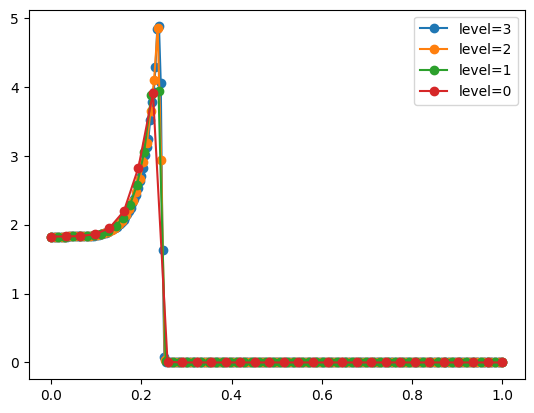

In [33]:
# plot data at difference resolutions
plt.clf()
for level in range(3,-1,-1):
    r, q, t = extract_data( 100, 'pressure', level)
    plt.plot(r, q, '-o', label='level=%d'%level)
plt.legend(loc=0)

In [30]:
# Plot data at different times
data = np.stack(
            [ extract_data(iteration, 'density', level=3)[1] \
             for iteration in range(0,150,10) ])

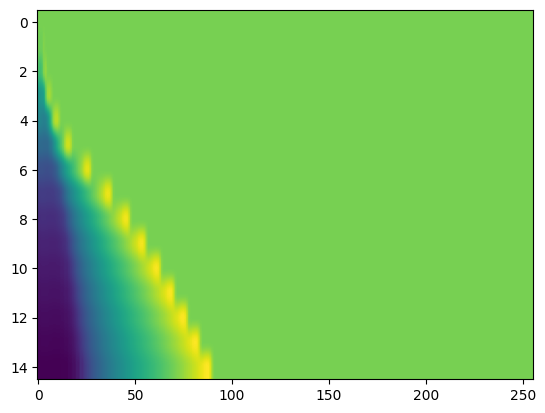

In [31]:
plt.imshow( np.log(data), aspect='auto' )